In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import functools
conn = duckdb.connect()
@functools.lru_cache(maxsize=1024)
def q(query: str):
    return conn.execute(query).df()

In [2]:
%cd analysis

/home/isaackhor/code/cfcache/analysis


In [5]:
# print(q('''select count(distinct key) from '../traces/cf/**/*.parquet' '''))
print(q('''select sum(size) from '../traces/cf/**/*.parquet' '''))
print(q('''select count(*) from '../traces/cf/**/*.parquet' '''))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      sum(size)
0  1.374085e+15
   count_star()
0    3937371920


In [44]:
# source rename for review anonymisation
rename_tbl = {
    'cf_a': 'BOS 1',
    'cf_b': 'BOS 2',
    'cf_c': 'DXB 1',
    'cf_d': 'DXB 2',
    'cf_e': 'SIN 1',
    'cf_f': 'SIN 2',
    'cf_g': 'FRA 1',
    'cf_h': 'FRA 2',
    'fb_a': 'Meta 1',
    'fb_b': 'Meta 2',
    'fb_c': 'Meta 3',
    'wm_t': 'WM 1',
    'wm_u': 'WM 2',

    '106m105': 'BOS 1',
    '106m106': 'BOS 2',
    '243m12': 'DXB 1',
    '243m13': 'DXB 2',
    '411m264': 'SIN 1',
    '411m325': 'SIN 2',
    '472m378': 'FRA 1',
    '472m379': 'FRA 2',

    'fb_reag' : 'Meta 1',
    'fb_rhna' : 'Meta 2',
    'fb_rprn' : 'Meta 3',
}

# fig 1: distribtion of miss types in baseline

In [4]:
files = [
    '../results/r9i2_baseline_keep.csv',
]
df = pd.concat([pd.read_csv(f) for f in files])

df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['miss_mandatory_pct'] = df.miss_mandatory / df.miss_all
df['miss_expired_pct'] = df.miss_expired / df.miss_all
df['miss_evicted_pct'] = df.miss_evicted / df.miss_all
df['in_lbl'] = df['in'].map(rename_tbl).fillna(df['in'])

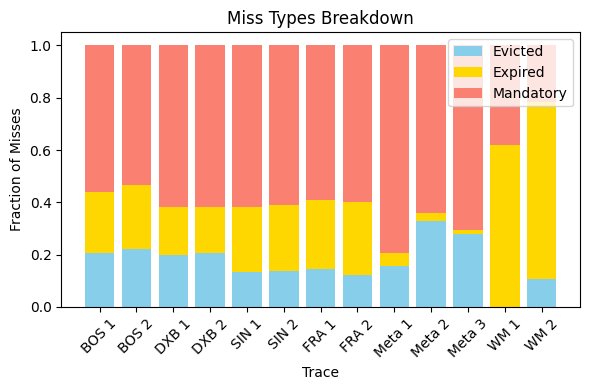

In [9]:
# get stacked bar plot of miss types
miss_types = df[df.cache_type == 'arc']
miss_types = miss_types.sort_values(by='in')
plt.figure(figsize=(6, 4))
plt.bar(miss_types['in_lbl'], miss_types['miss_evicted_pct'], label='Evicted', color='skyblue')
plt.bar(miss_types['in_lbl'], miss_types['miss_expired_pct'], bottom=miss_types['miss_evicted_pct'], label='Expired', color='gold')
plt.bar(miss_types['in_lbl'], miss_types['miss_mandatory_pct'], bottom=miss_types['miss_evicted_pct'] + miss_types['miss_expired_pct'], label='Mandatory', color='salmon')
plt.xlabel('Trace')
plt.ylabel('Fraction of Misses')
plt.title('Miss Types Breakdown')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../paper/figs/miss_types_by_trace.png')

# singletons

<Figure size 600x400 with 0 Axes>

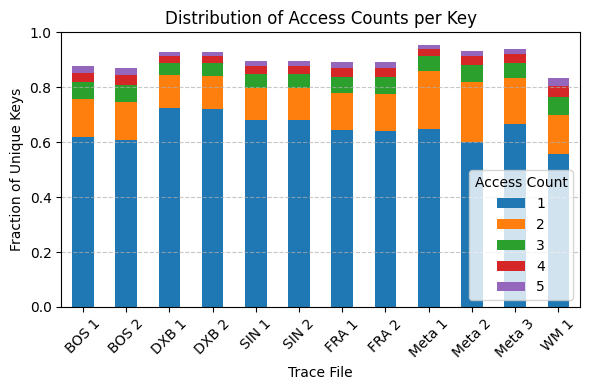

In [37]:
# Execute the query
df = q("""
WITH key_counts AS (
    SELECT 'Meta 1' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/reag.parquet' GROUP BY key
    UNION ALL
    SELECT 'Meta 2' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/rhna.parquet' GROUP BY key
    UNION ALL
    SELECT 'Meta 3' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/rprn.parquet' GROUP BY key
    UNION ALL
    SELECT server AS trace, key, COUNT(*) AS access_count FROM '../traces/cf/**/*.parquet' GROUP BY server, key
    UNION ALL
    SELECT 'WM 1' AS trace, key, COUNT(*) AS access_count FROM '../traces/wm/t-all.parquet' GROUP BY key
)
SELECT
    trace,
    SUM(CASE WHEN access_count = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a1,
    SUM(CASE WHEN access_count = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a2,
    SUM(CASE WHEN access_count = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a3,
    SUM(CASE WHEN access_count = 4 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a4,
    SUM(CASE WHEN access_count = 5 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a5
FROM key_counts
GROUP BY trace
ORDER BY trace
""")

# Display Table
# print(df)
df['trace_lbl'] = df['trace'].map(rename_tbl).fillna(df['trace'])

# Create Stacked Bar Chart
plt.figure(figsize=(6, 4))
df.set_index('trace_lbl').plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Distribution of Access Counts per Key')
plt.ylabel('Fraction of Unique Keys')
plt.xlabel('Trace File')
plt.xticks(rotation=45)
plt.legend(title='Access Count', labels=['1', '2', '3', '4', '5'], loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../paper/figs/access_count_distribution.png')
plt.show()

# TTL distributions

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_878470/2076537765.py:71: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(-10, xmax)


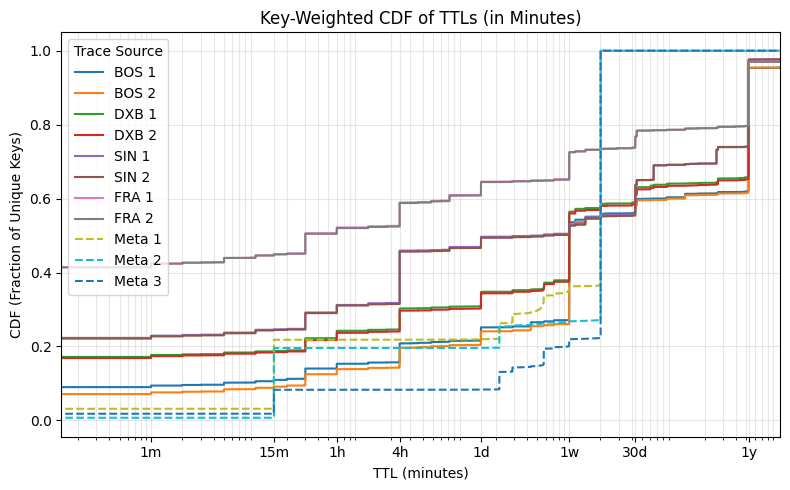

In [38]:
df_cf = q("""
SELECT 
    server AS trace, 
    FLOOR(expiry_time / 60) AS ttl_min, 
    COUNT(DISTINCT key) AS key_count 
FROM '../traces/cf/**/*.parquet' 
GROUP BY server, ttl_min
""")

df_fb_a = q('''
SELECT 
    'fb_reag' AS trace, 
    FLOOR(ttl / 60) AS ttl_min, 
    COUNT(DISTINCT cacheKey) AS key_count 
FROM '../traces/fb23/reag.parquet' 
GROUP BY ttl_min
''')

df_fb_b = q('''
SELECT 
    'fb_rhna' AS trace, 
    FLOOR(ttl / 60) AS ttl_min, 
    COUNT(DISTINCT cacheKey) AS key_count 
FROM '../traces/fb23/rhna.parquet' 
GROUP BY ttl_min
''')

df_fb_c = q('''
SELECT 
    'fb_rprn' AS trace, 
    FLOOR(ttl / 60) AS ttl_min, 
    COUNT(DISTINCT cacheKey) AS key_count 
FROM '../traces/fb23/rprn.parquet' 
GROUP BY ttl_min
''')

df = pd.concat([df_cf, df_fb_a, df_fb_b, df_fb_c])
df['trace_lbl'] = df['trace'].map(rename_tbl).fillna(df['trace'])

plt.figure(figsize=(8, 5))
xmax = 525600 * 2

for trace in sorted(df_cf['trace'].unique()):
    subset = df[df['trace'] == trace].sort_values('ttl_min')
    subset['cum_keys'] = subset['key_count'].cumsum()
    subset['cdf'] = subset['cum_keys'] / subset['key_count'].sum()
    plt.step(subset['ttl_min'], subset['cdf'], label=rename_tbl[trace], where='post')

for trace in sorted(['fb_reag', 'fb_rhna', 'fb_rprn']):
    subset = df[df['trace'] == trace].sort_values('ttl_min')
    subset['cum_keys'] = subset['key_count'].cumsum()
    subset['cdf'] = subset['cum_keys'] / subset['key_count'].sum()
    if not subset.empty and subset['cdf'].iloc[-1] >= 1.0 and subset['ttl_min'].iloc[-1] < xmax:
        subset = pd.concat([
            subset,
            pd.DataFrame({'ttl_min': [xmax], 'cdf': [1.0]})
        ], ignore_index=True)
    plt.step(subset['ttl_min'], subset['cdf'], '--', label=rename_tbl[trace], where='post')

# X-axis formatting
plt.xscale('log')
plt.xlabel('TTL (minutes)')
plt.ylabel('CDF (Fraction of Unique Keys)')
plt.title('Key-Weighted CDF of TTLs (in Minutes)')

# Standardize ticks for easier reading
# 1m, 1h, 1d, 1w, 30d
ticks = [1, 15, 60, 240, 1440, 10080, 43200, 525600]
labels = ['1m', '15m', '1h', '4h', '1d', '1w', '30d', '1y']
plt.xticks(ticks, labels)
plt.xlim(-10, xmax)

plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(title='Trace Source')
plt.tight_layout()
plt.savefig('../paper/figs/ttl_cdf_by_key.png')
plt.show()

In [ ]:
# Expiry events distribution of TTLs


# results - oracle / ml tradeoff curves

In [82]:
files = [
    '../results/r9i2_baseline.csv',
    '../results/r9i2_oracle.csv',
    '../results/r9i4_ml_cf_rfc.csv',
    '../results/r9i4_ml_fb_rfc.csv',
    '../results/r9i4_ml_wm_rfc.csv',
]
df = pd.concat([pd.read_csv(f) for f in files])

df = df.drop(columns=['rv_min_ttl', 'rv_min_freq', 'rv_max_za'])
df = df.drop_duplicates().sort_values(by='in')
df['trace'] = df['in'].map(rename_tbl).fillna(df['in'])
df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['rv_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['optmiss'] = (df['miss_all'] - df['miss_mandatory']) / df['all'] * 100
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['rv_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2
df

,in,gib,ksr,cache_type,mode,model,mlthres,evict_expired,all,hit_fresh,...,fetches,revals,reval_wasted,trace,miss_all,rv_pending,optmiss,amp_lower,amp_upper,amp_avg
0,cf_a,2048,1,arc,ml,models/v9_cf_rfc.onnx,0.66,True,611934080,539668753,...,66413899,117762585,111900137,BOS 1,66413899,11020,4.415496,2.548462,2.548615,2.548539
34,cf_a,2048,1,lru,ml,models/v9_cf_rfc.onnx,0.90,True,611934080,546116460,...,64838115,1036098,54067,BOS 1,64838115,2526,4.157987,1.000821,1.000860,1.000841
35,cf_a,2048,1,lru,ml,models/v9_cf_rfc.onnx,0.95,True,611934080,546186945,...,65515917,234935,3533,BOS 1,65515917,184,4.268751,1.000054,1.000057,1.000055
36,cf_a,2048,1,lru,ml,models/v9_cf_rfc.onnx,1.00,True,611934080,546199566,...,65734514,0,0,BOS 1,65734514,0,4.304473,1.000000,1.000000,1.000000
37,cf_a,2048,1,sieve,ml,models/v9_cf_rfc.onnx,0.66,True,611934080,544039469,...,61704947,181310029,175091926,BOS 1,61704947,28439,3.645976,3.578878,3.579297,3.579088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,wm_u,2048,1,fifo,oracle,NaN,1.00,True,2656114237,2410980760,...,104071151,141062326,0,WM 2,104071151,0,2.046339,1.000000,1.000000,1.000000
254,wm_u,2048,1,arc,oracle,NaN,4.00,True,2656114237,2404315117,...,65691471,251260680,65153031,WM 2,65691471,0,0.601383,1.258750,1.258750,1.258750
253,wm_u,2048,1,arc,oracle,NaN,3.00,True,2656114237,2405156156,...,72002531,224288000,45332450,WM 2,72002531,0,0.838988,1.180638,1.180638,1.180638
264,wm_u,2048,1,lru,oracle,NaN,1.00,True,2656114237,2406820867,...,82537353,189809505,2305348888,WM 2,82537353,-2282295400,1.235614,10.247534,1.092475,5.670005


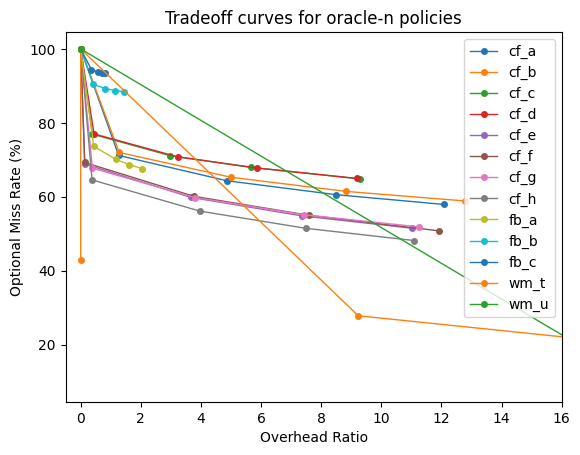

In [73]:
oracledf = df[(df['cache_type'] == 'lru') & ((df['mode'] == 'oracle') | (df['mode'] == 'never'))]
for i in sorted(oracledf['in'].unique()):
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = oracledf[oracledf['in'] == i].sort_values(by='amp_avg')
    plt.plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='o', ms=4, linewidth=1, label=i)
plt.xlim(-0.5, 16)
plt.legend()
plt.title('Tradeoff curves for oracle-n policies')
plt.xlabel('Overhead Ratio')
plt.ylabel('Optional Miss Rate (%)')
plt.savefig('../paper/figs/oracle_tradeoff.png')

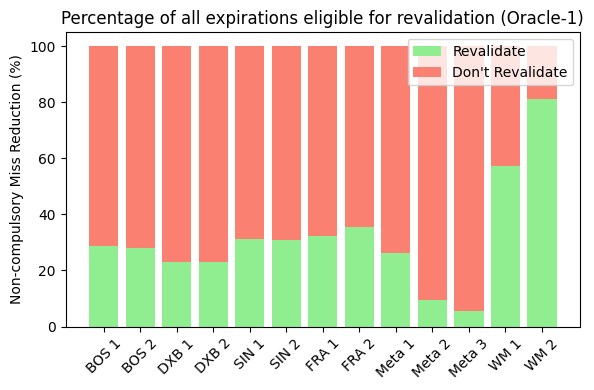

In [81]:
oracledf[(oracledf['mlthres'] == 1)]

plt.figure(figsize=(6, 4))
ndf = oracledf[oracledf['mode'] == 'never'].sort_values(by='in').reset_index()
odf = oracledf[(oracledf['mode'] == 'oracle') & (oracledf['mlthres'] == 1)].sort_values(by='in').reset_index()

max_improvement = 100 - (odf['optmiss'] / ndf['optmiss'] * 100)
plt.bar(odf['trace'], max_improvement, color='lightgreen', label='Revalidate')
plt.bar(odf['trace'], 100-max_improvement, bottom=max_improvement, color='salmon', label="Don't Revalidate")
plt.xticks(rotation=45)
plt.title('Percentage of all expirations eligible for revalidation (Oracle-1)')
plt.ylabel('Non-compulsory Miss Reduction (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../paper/figs/oracle_eligible.png')

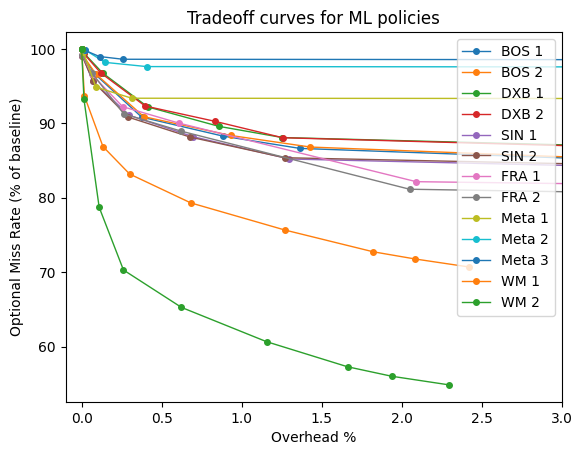

In [86]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg']]
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    plt.plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='o', ms=4, linewidth=1, label=trace)
plt.xlim(-0.1, 3)
plt.legend(loc='upper right')
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Overhead %')
plt.ylabel('Optional Miss Rate (% of baseline)')
plt.savefig('../paper/figs/ml_tradeoff_norm.png')

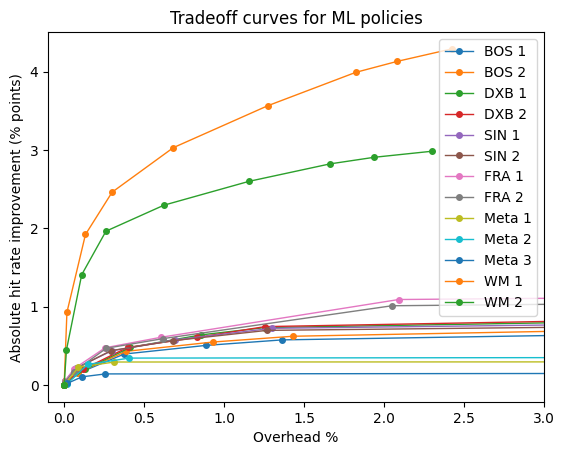

In [87]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg']]
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    plt.plot((subset['amp_avg'] - 1) * 100, nevermax - subset['optmiss'], marker='o', ms=4, linewidth=1, label=trace)
plt.legend()
plt.xlim(-0.1, 3)
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Overhead %')
plt.ylabel('Absolute hit rate improvement (% points)')
plt.savefig('../paper/figs/ml_tradeoff_abs.png')

In [ ]:
trace = 'cf_a'
mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
for ct in df['cache_type'].unique():
    nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
    oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
    subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
    pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
    plt.plot((subset['amp_avg'] - 1) * 100, pc_oracle, marker='o', ms=4, linewidth=1, label=ct)
plt.legend()
plt.title(f'Tradeoff curves for ML policies, relative to oracle-1, trace={trace}')
plt.xlabel('Overhead %')
plt.ylabel('Relative hit rate improvement (% of oracle)')
plt.savefig('../paper/figs/ml_tradeoff_by_eviction.png')

In [100]:
nvm = df[(df['mode'] == 'never') & (df['cache_type'] == 'lru')]['optmiss']
orm = df[(df['mode'] == 'oracle') & (df['mlthres'] == 1) & (df['cache_type'] == 'lru')]['optmiss']

19    cf_a
16    cf_b
4     cf_c
8     cf_d
42    cf_e
23    cf_f
52    cf_g
59    cf_h
29    fb_a
37    fb_b
41    fb_c
62    wm_t
66    wm_u
Name: in, dtype: object

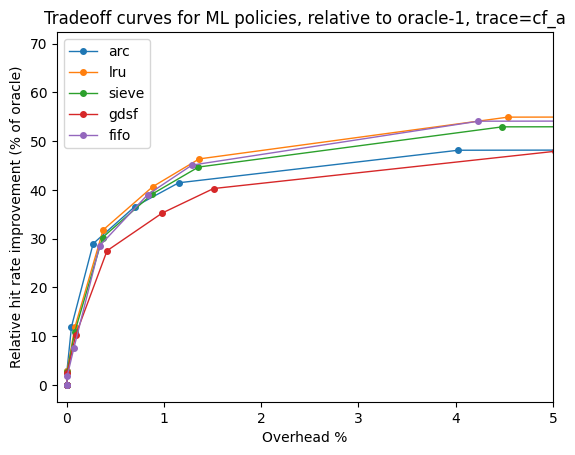

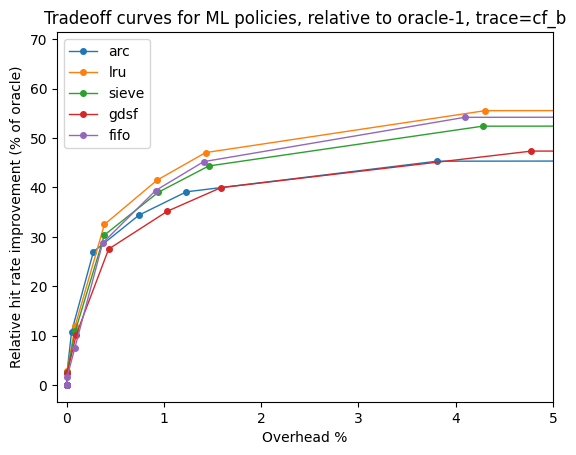

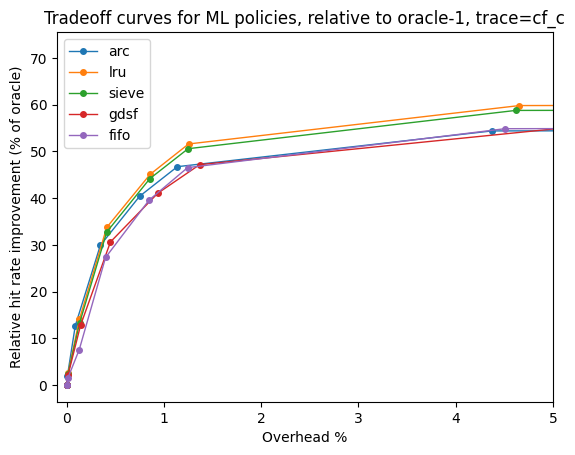

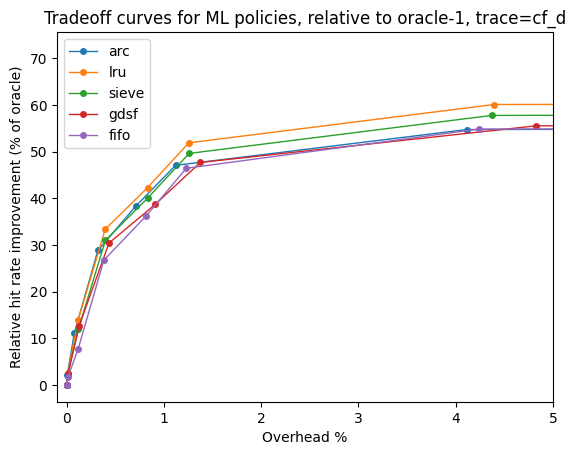

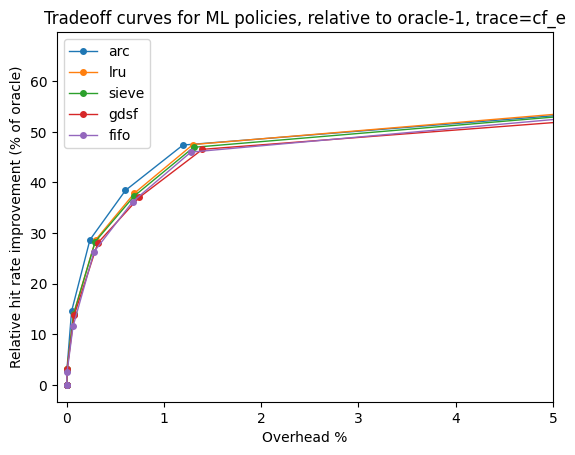

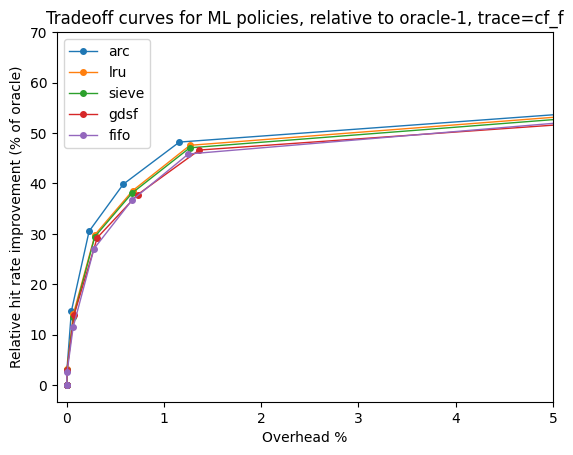

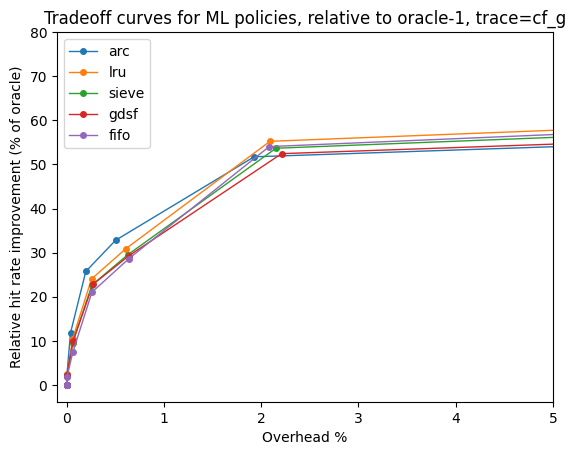

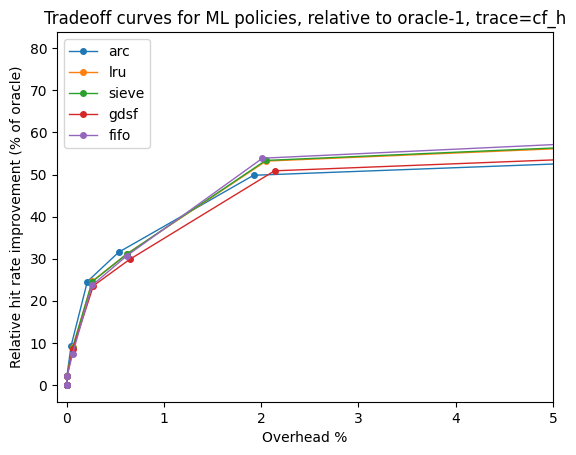

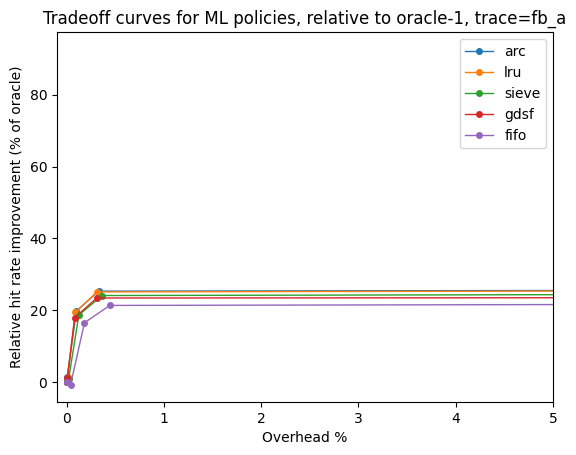

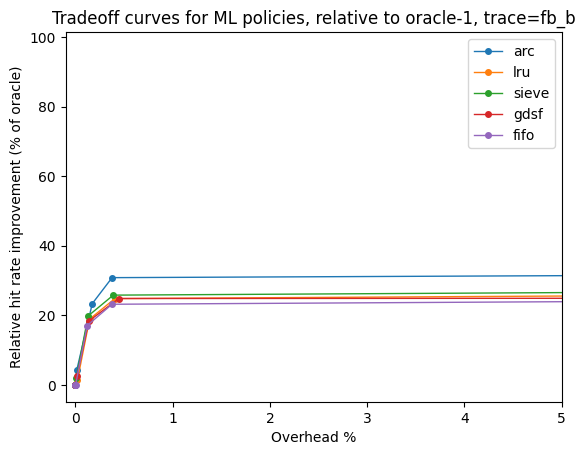

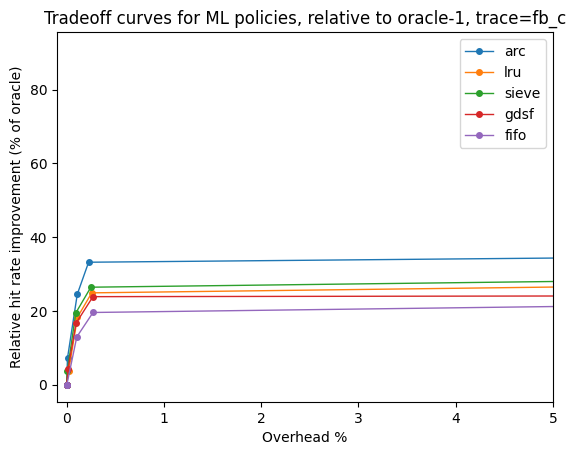

In [114]:
for trace in ['cf_a', 'cf_b', 'cf_c', 'cf_d', 'cf_e', 'cf_f', 'cf_g', 'cf_h', 'fb_a', 'fb_b', 'fb_c']:
    mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
    for ct in df['cache_type'].unique():
        nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
        oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
        subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
        pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
        plt.plot((subset['amp_avg'] - 1) * 100, pc_oracle, marker='o', ms=4, linewidth=1, label=ct)
    plt.legend()
    plt.title(f'Tradeoff curves for ML policies, relative to oracle-1, trace={trace}')
    plt.xlim(-0.1, 5)
    plt.xlabel('Overhead %')
    plt.ylabel('Relative hit rate improvement (% of oracle)')
    plt.show()
    # plt.savefig('../paper/figs/ml_tradeoff_by_eviction.png')

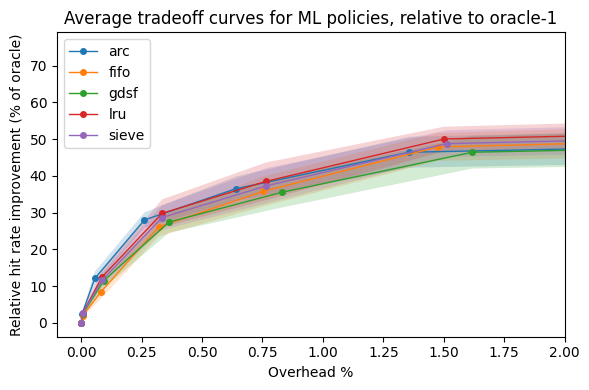

In [119]:
traces = ['cf_a', 'cf_b', 'cf_c', 'cf_d', 'cf_e', 'cf_f', 'cf_g', 'cf_h']
rows = []
for trace in traces:
    mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
    for ct in df['cache_type'].unique():
        nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
        oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
        subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
        pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
        rows.append(pd.DataFrame({
            'cache_type': ct,
            'mlthres': subset['mlthres'].values,
            'amp_avg': subset['amp_avg'].values,
            'pc_oracle': pc_oracle.values
        }))

alldf = pd.concat(rows, ignore_index=True)
agg = alldf.groupby(['cache_type', 'mlthres']).agg(
    pc_oracle_mean=('pc_oracle', 'mean'),
    pc_oracle_std=('pc_oracle', 'std'),
    amp_avg_mean=('amp_avg', 'mean')
).reset_index()

plt.figure(figsize=(6, 4))
for ct in sorted(agg['cache_type'].unique()):
    sub = agg[agg['cache_type'] == ct].sort_values('mlthres')
    x = (sub['amp_avg_mean'] - 1) * 100
    y = sub['pc_oracle_mean']
    yerr = sub['pc_oracle_std'].fillna(0)
    plt.plot(x, y, marker='o', ms=4, linewidth=1, label=ct)
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)

plt.legend()
plt.title('Average tradeoff curves for ML policies, relative to oracle-1')
plt.xlim(-0.1, 2)
plt.xlabel('Overhead %')
plt.ylabel('Relative hit rate improvement (% of oracle)')
plt.tight_layout()
plt.savefig('../paper/figs/ml_tradeoff_by_eviction_avg.png')
plt.show()

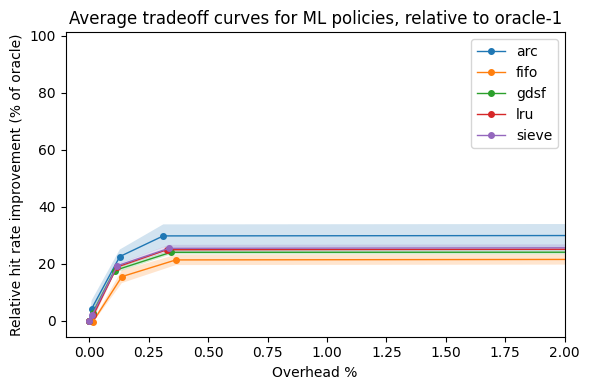

In [118]:
traces = ['fb_a', 'fb_b', 'fb_c']
rows = []
for trace in traces:
    mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
    for ct in df['cache_type'].unique():
        nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
        oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
        subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
        pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
        rows.append(pd.DataFrame({
            'cache_type': ct,
            'mlthres': subset['mlthres'].values,
            'amp_avg': subset['amp_avg'].values,
            'pc_oracle': pc_oracle.values
        }))

alldf = pd.concat(rows, ignore_index=True)
agg = alldf.groupby(['cache_type', 'mlthres']).agg(
    pc_oracle_mean=('pc_oracle', 'mean'),
    pc_oracle_std=('pc_oracle', 'std'),
    amp_avg_mean=('amp_avg', 'mean')
).reset_index()

plt.figure(figsize=(6, 4))
for ct in sorted(agg['cache_type'].unique()):
    sub = agg[agg['cache_type'] == ct].sort_values('mlthres')
    x = (sub['amp_avg_mean'] - 1) * 100
    y = sub['pc_oracle_mean']
    yerr = sub['pc_oracle_std'].fillna(0)
    plt.plot(x, y, marker='o', ms=4, linewidth=1, label=ct)
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)

plt.legend()
plt.title('Average tradeoff curves for ML policies, relative to oracle-1')
plt.xlim(-0.1, 2)
plt.xlabel('Overhead %')
plt.ylabel('Relative hit rate improvement (% of oracle)')
plt.tight_layout()
# plt.savefig('../paper/figs/ml_tradeoff_by_eviction_avg.png')
plt.show()